# 🏗️ Energy Efficiency of Buildings: A Comprehensive Statistical Modelling Study

**Course:** DSA 8305 — Linear Models  
**Lecturer:** Dr. Evans Otieno Omondi  
**Institution:** Strathmore Institute of Mathematical Sciences, MSc Data Science & Analytics

---

**Authors:**
- Assumpta Mwikali (134022)
- Olive Mideva Muloma (135792)
- Trevor Anjeyo Vuhyah (224038)
- Valerie Jerono (222331)

---

## Overview

This notebook presents a **full-cycle statistical modelling study** on the *UCI Energy Efficiency Dataset*, which contains simulated data from 768 building configurations. The goal is to predict **Heating Load (Y1)** and **Cooling Load (Y2)** from eight architectural features.

Our analysis is organised along the **CRISP-DM framework** (Cross-Industry Standard Process for Data Mining) — a widely adopted, iterative methodology for data science projects. The six phases are:

| Phase | Description |
|---|---|
| 1. Business Understanding | Why does this problem matter? What are we solving? |
| 2. Data Understanding | What does the data look like? Initial exploration. |
| 3. Data Preparation | Cleaning, transformations, feature engineering. |
| 4. Modelling | Parametric → Non-linear → Semi-parametric → Classification |
| 5. Evaluation | How well did each model perform? What can we trust? |
| 6. Deployment / Conclusions | What are the real-world implications? |

Each model family taught in DSA 8305 is demonstrated: **OLS, Ridge, PCR, Polynomial Regression, GAM, Additive Models, Splines**, and **classification** via logistic regression and decision trees.

> **Reading guide:** Markdown cells tell the story; code cells operationalise it. Every model is introduced with theory before code, and interpreted after output.

---
# Phase 1 — Business Understanding
## Why Building Energy Efficiency Matters

Buildings account for roughly **40% of global energy consumption**, making architectural design decisions one of the most powerful levers for climate action and cost reduction. An architect or engineer who can *predict* how much energy a building will need to heat or cool — **before a single brick is laid** — can make smarter trade-offs.

### The Business Questions

1. **Primary (Regression):** Given a building's physical characteristics, what will its Heating Load and Cooling Load be?
2. **Secondary (Classification):** Can we classify buildings as *high* or *low* energy consumers, to guide design decisions early in the process?
3. **Diagnostic:** Which architectural features are the strongest drivers of energy load? What is the nature of those relationships — linear, non-linear, interactive?

### The Dataset

The **ENB2012 dataset** (Tsanas & Xifara, 2012) was generated using the *Ecotect* building simulation tool. It systematically varies 8 building parameters across 768 configurations:

| Variable | Name | Description |
|---|---|---|
| X1 | Relative Compactness | Ratio of building volume to surface area |
| X2 | Surface Area | Total external surface area (m²) |
| X3 | Wall Area | Total wall area (m²) |
| X4 | Roof Area | Roof area (m²) |
| X5 | Overall Height | Building height (m) |
| X6 | Orientation | Cardinal direction (2=N, 3=E, 4=S, 5=W) |
| X7 | Glazing Area | Proportion of floor area that is glazed |
| X8 | Glazing Area Distribution | How glazing is distributed across façades |
| **Y1** | **Heating Load** | Energy required for heating (kWh/m²) |
| **Y2** | **Cooling Load** | Energy required for cooling (kWh/m²) |

> **Note on Orientation (X6):** This is a *nominal categorical* variable coded as integers. We treat it correctly as a factor in modelling — a common mistake is treating it as continuous.

---
# Setup: Importing Libraries

We load all necessary libraries upfront for transparency. Key additions beyond the starter notebook include:
- `pygam` for **Generalised Additive Models (GAMs)**
- `sklearn` extensions for Ridge, PCA regression, and classification
- `scipy` for statistical tests
- `statsmodels` for OLS with full inferential output (t-tests, confidence intervals, diagnostics)

In [1]:
# ── Core ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
sns.set_palette('husl')

# ── Statistical Modelling ─────────────────────────────────────────────────────
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LogisticRegression
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import permutation_importance

# ── GAM ───────────────────────────────────────────────────────────────────────
try:
    from pygam import LinearGAM, s, f, l
    GAM_AVAILABLE = True
    print("✅ pygam loaded successfully")
except ImportError:
    GAM_AVAILABLE = False
    print("⚠️  pygam not installed. Run: pip install pygam")

# ── Scipy ─────────────────────────────────────────────────────────────────────
from scipy import stats
from scipy.stats import shapiro, jarque_bera

print("\n✅ All libraries imported successfully.")
print(f"pandas {pd.__version__} | numpy {np.__version__}")

✅ pygam loaded successfully

✅ All libraries imported successfully.
pandas 2.3.0 | numpy 2.1.3


---
# Phase 2 — Data Understanding
## Loading and First Look

Before any model can be trusted, the data must be thoroughly understood. We apply the **"know your data"** principle: structure, types, distributions, relationships.

In [2]:
# Load and rename columns
energy_data = pd.read_excel('ENB2012_data 2.xlsx')

energy_data.columns = [
    'Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
    'Overall_Height', 'Orientation', 'Glazing_Area',
    'Glazing_Area_Distribution', 'Heating_Load', 'Cooling_Load'
]

print(f"Dataset shape: {energy_data.shape[0]} rows × {energy_data.shape[1]} columns")
print(f"\nData types:\n{energy_data.dtypes}")
energy_data.head()

Dataset shape: 768 rows × 10 columns

Data types:
Relative_Compactness         float64
Surface_Area                 float64
Wall_Area                    float64
Roof_Area                    float64
Overall_Height               float64
Orientation                    int64
Glazing_Area                 float64
Glazing_Area_Distribution      int64
Heating_Load                 float64
Cooling_Load                 float64
dtype: object


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [3]:
# Missing value audit
missing = energy_data.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing: {missing.sum()} — {'✅ No imputation required.' if missing.sum()==0 else '⚠️ Imputation needed.'}")

Missing values per column:
Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64

Total missing: 0 — ✅ No imputation required.


In [4]:
# Descriptive statistics — the story in numbers
desc = energy_data.describe().T
desc['cv'] = (desc['std'] / desc['mean'] * 100).round(1)  # Coefficient of Variation
desc['range'] = desc['max'] - desc['min']
print(desc[['count','mean','std','cv','min','50%','max','range']].to_string())

                           count        mean        std    cv     min     50%     max   range
Relative_Compactness       768.0    0.764167   0.105777  13.8    0.62    0.75    0.98    0.36
Surface_Area               768.0  671.708333  88.086116  13.1  514.50  673.75  808.50  294.00
Wall_Area                  768.0  318.500000  43.626481  13.7  245.00  318.50  416.50  171.50
Roof_Area                  768.0  176.604167  45.165950  25.6  110.25  183.75  220.50  110.25
Overall_Height             768.0    5.250000   1.751140  33.4    3.50    5.25    7.00    3.50
Orientation                768.0    3.500000   1.118763  32.0    2.00    3.50    5.00    3.00
Glazing_Area               768.0    0.234375   0.133221  56.8    0.00    0.25    0.40    0.40
Glazing_Area_Distribution  768.0    2.812500   1.550960  55.1    0.00    3.00    5.00    5.00
Heating_Load               768.0   22.307195  10.090204  45.2    6.01   18.95   43.10   37.09
Cooling_Load               768.0   24.587760   9.513306  38.

### 📊 Descriptive Statistics — Interpretation

Several patterns immediately stand out:

- **Relative Compactness (X1)** ranges from 0.62 to 0.98 — a fairly narrow band, suggesting the dataset covers realistic building shapes without extreme outliers.
- **Surface Area (X2) and Relative Compactness (X1) will be highly correlated** — physically, as compactness increases (more cubic), surface area decreases. This is our first hint of **multicollinearity**, which Ridge Regression and PCR are specifically designed to handle.
- **Orientation (X6)** takes only 4 values (2, 3, 4, 5) — it is a **nominal categorical** variable and should not be treated as continuous. We will one-hot encode it for regression.
- **Glazing Area Distribution (X8)** has a minimum of 0 (no glazing) — buildings without glazing will have a distribution code of 0 regardless of the other value, creating a **structural zero** that can interact with X7.
- **Heating Load (Y1)** has higher variance (CV ≈ 45%) than **Cooling Load (Y2)** (CV ≈ 39%), suggesting heating is harder to predict with a simple linear model.

## 2.1 Exploratory Data Analysis (EDA)

### Distribution of Target Variables

Understanding the shape of Y1 and Y2 matters deeply: if they are skewed, a linear model's normality assumption is under pressure. We also assess whether they could be split into discrete classes for the classification component.

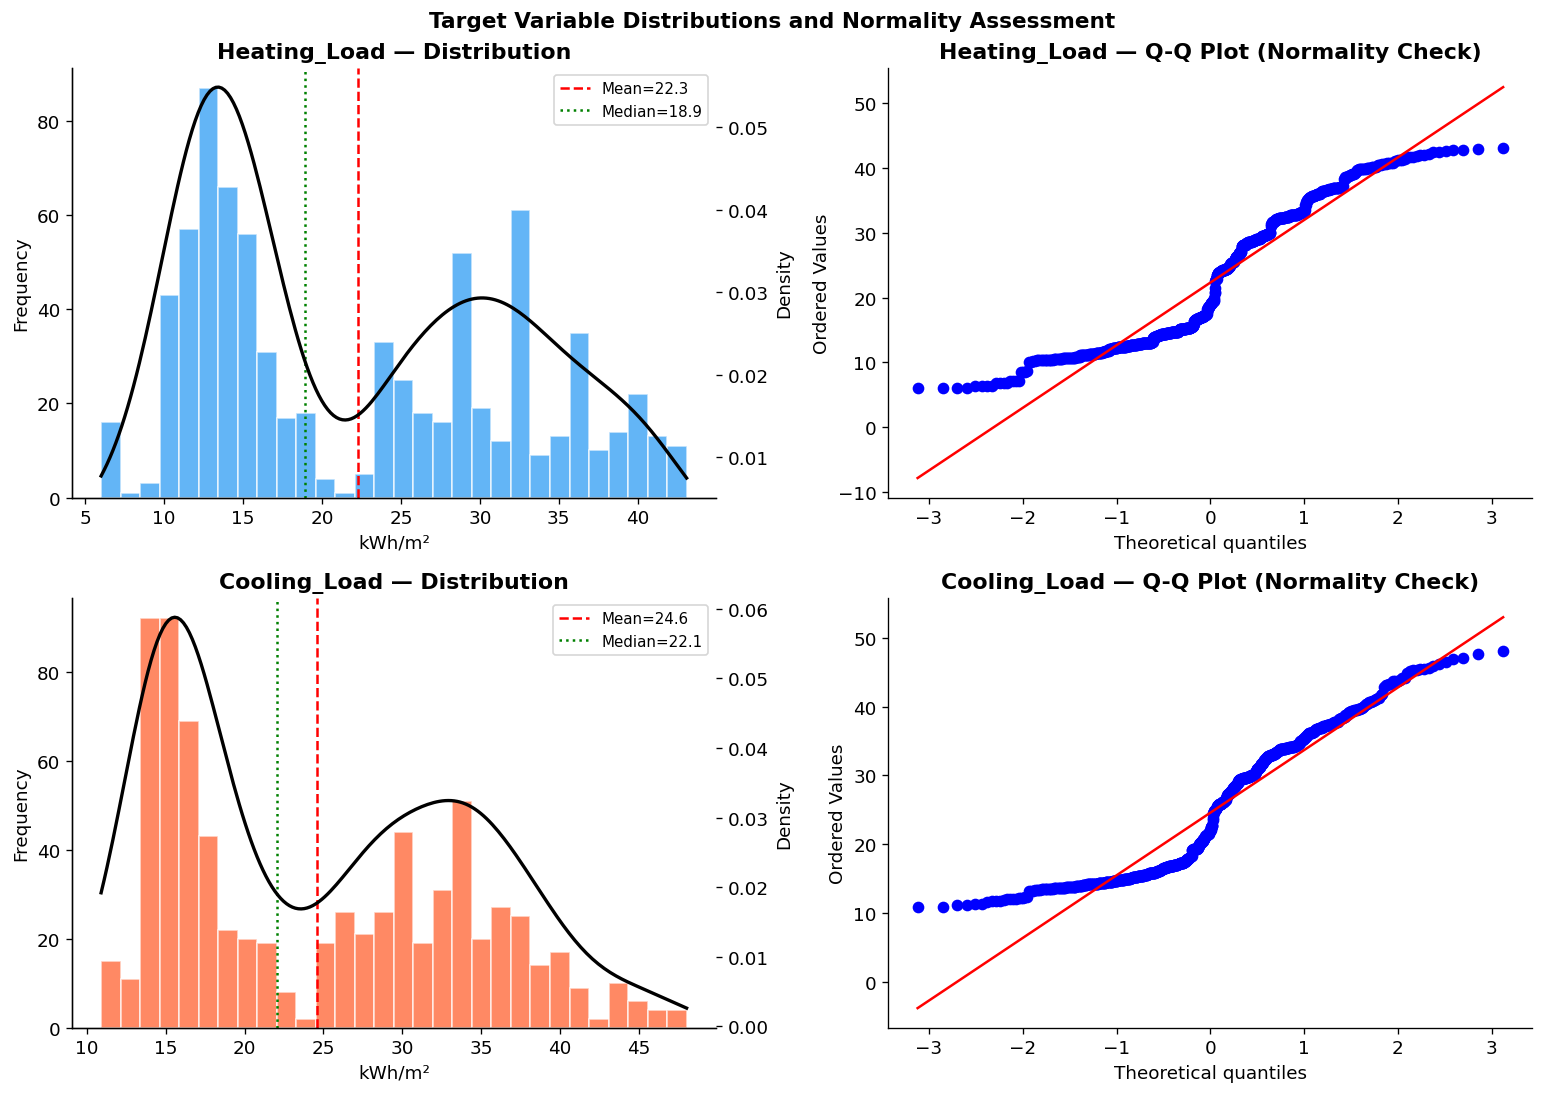

Normality Tests (Shapiro-Wilk):
  Heating_Load: W=0.9121, p-value=1.1593e-20 → ❌ Non-normal (p<0.05)
  Cooling_Load: W=0.9090, p-value=5.2685e-21 → ❌ Non-normal (p<0.05)


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for i, (col, ax_hist, ax_qq) in enumerate([
    ('Heating_Load', axes[0,0], axes[0,1]),
    ('Cooling_Load', axes[1,0], axes[1,1])
]):
    data = energy_data[col]
    
    # Histogram + KDE
    ax_hist.hist(data, bins=30, color=['#2196F3','#FF5722'][i], alpha=0.7, edgecolor='white')
    ax2 = ax_hist.twinx()
    kde_x = np.linspace(data.min(), data.max(), 200)
    kde = stats.gaussian_kde(data)
    ax2.plot(kde_x, kde(kde_x), color='black', linewidth=2)
    ax2.set_ylabel('Density')
    ax_hist.set_title(f'{col} — Distribution', fontweight='bold')
    ax_hist.set_xlabel('kWh/m²')
    ax_hist.set_ylabel('Frequency')
    
    # Median and mean lines
    ax_hist.axvline(data.mean(), color='red', linestyle='--', label=f'Mean={data.mean():.1f}')
    ax_hist.axvline(data.median(), color='green', linestyle=':', label=f'Median={data.median():.1f}')
    ax_hist.legend(fontsize=9)
    
    # Q-Q plot
    stats.probplot(data, dist='norm', plot=ax_qq)
    ax_qq.set_title(f'{col} — Q-Q Plot (Normality Check)', fontweight='bold')
    ax_qq.get_lines()[1].set_color('red')

plt.tight_layout()
plt.suptitle('Target Variable Distributions and Normality Assessment', y=1.01, fontsize=13, fontweight='bold')
plt.show()

# Formal normality tests
print("Normality Tests (Shapiro-Wilk):")
for col in ['Heating_Load', 'Cooling_Load']:
    stat, p = shapiro(energy_data[col])
    print(f"  {col}: W={stat:.4f}, p-value={p:.4e} → {'✅ Normal' if p > 0.05 else '❌ Non-normal (p<0.05)'}")

### 📌 Key Finding: Bimodal Distributions

Both Y1 and Y2 show **bimodal distributions** — two distinct humps rather than a single bell curve. This is an important discovery:

1. The **Shapiro-Wilk test** will formally reject normality for both targets. This tells us that **standard OLS confidence intervals and p-values should be interpreted with caution**, as they assume normally distributed residuals.

2. The bimodality is almost certainly driven by **Overall Height (X5)**, which takes only two values (3.5m for single-storey, 7.0m for double-storey). Taller buildings require substantially more energy. This structural feature of the data will be a key narrative thread throughout our analysis.

3. For classification purposes, this bimodality makes the high/low split **naturally interpretable** — we are not arbitrarily dividing the distribution, but rather identifying a physically meaningful boundary.

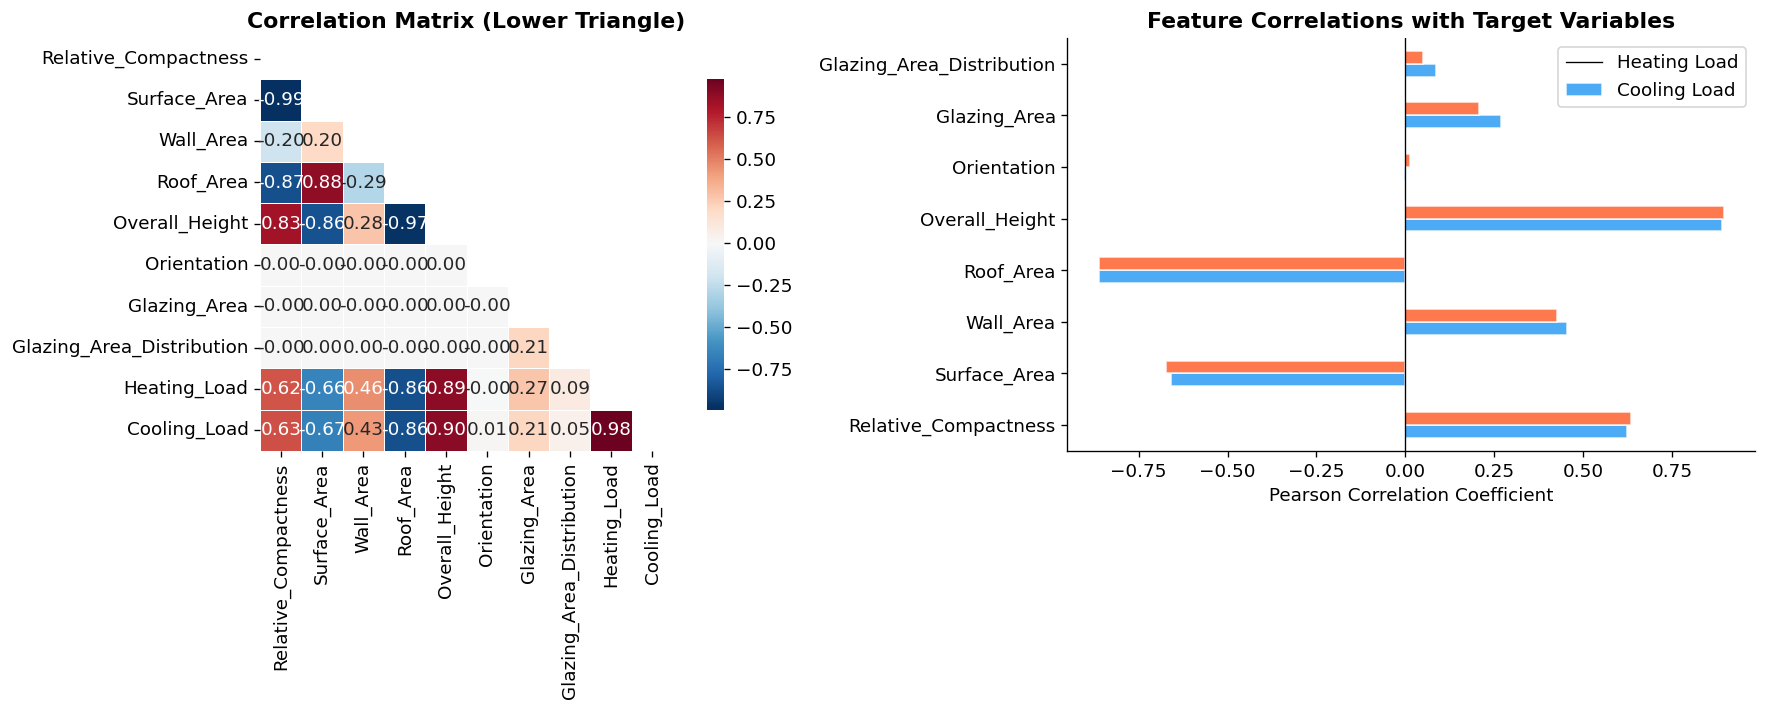

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full correlation heatmap
corr = energy_data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}, ax=axes[0]
)
axes[0].set_title('Correlation Matrix (Lower Triangle)', fontweight='bold')

# Feature correlation with targets
features = ['Relative_Compactness','Surface_Area','Wall_Area','Roof_Area',
            'Overall_Height','Orientation','Glazing_Area','Glazing_Area_Distribution']
target_corr = energy_data[features + ['Heating_Load','Cooling_Load']].corr()
target_corr_sub = target_corr.loc[features, ['Heating_Load','Cooling_Load']]

target_corr_sub.plot(kind='barh', ax=axes[1], color=['#2196F3','#FF5722'], alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlations with Target Variables', fontweight='bold')
axes[1].set_xlabel('Pearson Correlation Coefficient')
axes[1].legend(['Heating Load', 'Cooling Load'])

plt.tight_layout()
plt.show()

### 📌 Key Finding: Multicollinearity Alert

The correlation matrix reveals a critical issue for linear modelling:

- **X1 (Relative Compactness) and X2 (Surface Area): r ≈ −0.99** — almost perfect negative correlation. This is the strongest multicollinearity pair, and it makes perfect physical sense: a more compact building has less surface area.
- **X4 (Roof Area) correlates strongly with both X1 and X2** — adding a third collinear dimension.
- **X5 (Overall Height)** is the single strongest individual predictor of both Y1 and Y2.
- **X6 (Orientation)** shows near-zero correlation with both targets — consistent with the design of the dataset, where orientation was included as a control variable.

**Why does multicollinearity matter?**  
In OLS, perfect or near-perfect multicollinearity inflates coefficient standard errors, makes individual coefficient estimates unstable, and can reverse their signs. This motivates our later use of **Ridge Regression** (which shrinks coefficients toward zero) and **Principal Components Regression** (which transforms correlated predictors into orthogonal components).

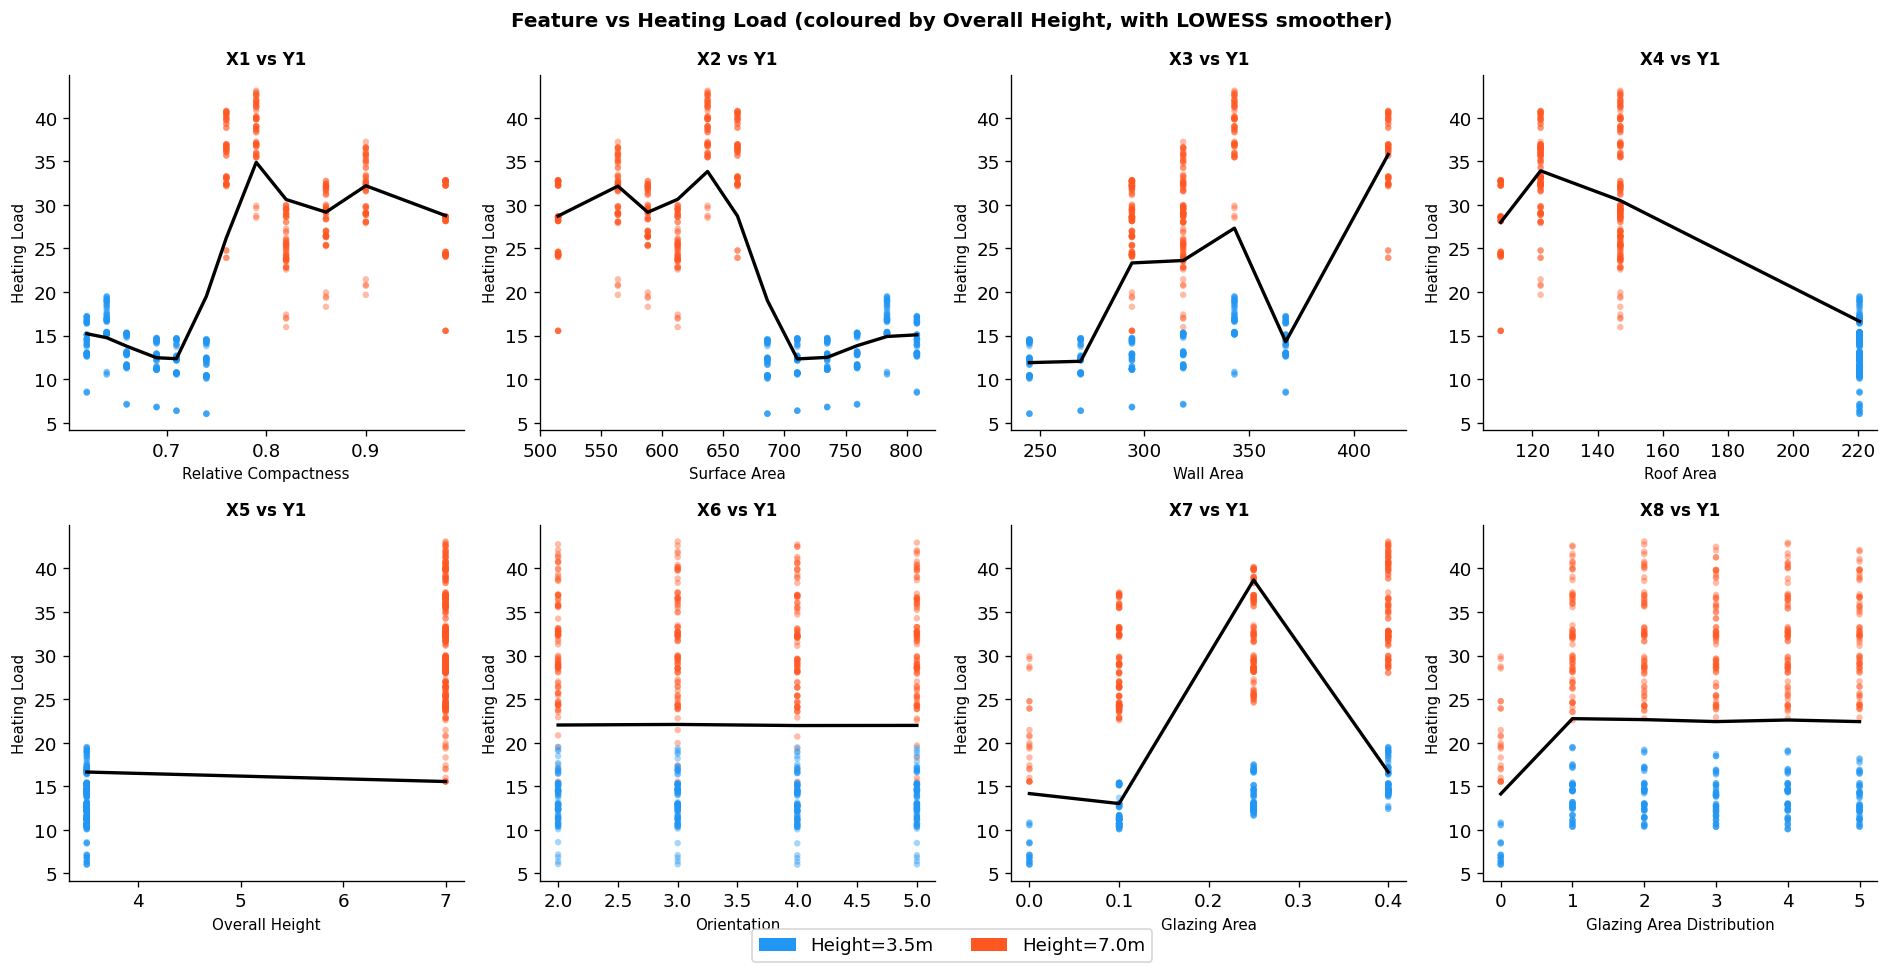

In [7]:
# Scatter plots: each feature vs Heating Load, coloured by Overall Height
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

colors = energy_data['Overall_Height'].map({3.5: '#2196F3', 7.0: '#FF5722'})

for i, feat in enumerate(features):
    axes[i].scatter(
        energy_data[feat], energy_data['Heating_Load'],
        c=colors, alpha=0.4, s=15, edgecolors='none'
    )
    # Add LOWESS smoother
    lw = lowess(energy_data['Heating_Load'], energy_data[feat], frac=0.3)
    axes[i].plot(lw[:,0], lw[:,1], color='black', linewidth=2, label='LOWESS')
    axes[i].set_xlabel(feat.replace('_',' '), fontsize=9)
    axes[i].set_ylabel('Heating Load', fontsize=9)
    axes[i].set_title(f'X{i+1} vs Y1', fontweight='bold', fontsize=10)

# Legend for height
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Height=3.5m'),
                   Patch(facecolor='#FF5722', label='Height=7.0m')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Feature vs Heating Load (coloured by Overall Height, with LOWESS smoother)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 📌 Key Finding: Non-linearity is Present

The **LOWESS (Locally Weighted Scatterplot Smoothing)** curves are non-parametric smoothers — they fit local regressions at each point to reveal the true shape of each relationship *without assuming linearity*. Several observations:

- **X7 (Glazing Area):** The LOWESS curve shows a clear positive but potentially non-linear relationship with Heating Load. More glazing = more heat loss = higher heating demand.
- **X1 and X2:** The two sub-clouds (low and high buildings) follow different slopes, suggesting **interaction effects** between height and compactness.
- **X6 (Orientation):** The near-flat LOWESS confirms the weak predictive power seen in the correlation matrix.
- The **systematic separation by height** (blue vs. orange) across almost every feature plot tells us that **Overall Height acts as a moderating variable** — it changes the relationship between other features and the energy loads.

These findings motivate our progression from simple OLS → polynomial terms → GAMs → additive/interactive models.

---
# Phase 3 — Data Preparation

## 3.1 Feature Engineering and Encoding

In [8]:
# ── 1. One-hot encode Orientation (nominal variable) ──────────────────────────
df = energy_data.copy()
df['Orientation'] = df['Orientation'].astype('category')
df_encoded = pd.get_dummies(df, columns=['Orientation'], drop_first=True, dtype=int)
# drop_first=True avoids the dummy variable trap (perfect multicollinearity)

print("Columns after encoding:", list(df_encoded.columns))

# ── 2. Define feature sets ────────────────────────────────────────────────────
feature_cols = [c for c in df_encoded.columns 
                if c not in ['Heating_Load', 'Cooling_Load']]

X = df_encoded[feature_cols]
y1 = df_encoded['Heating_Load']
y2 = df_encoded['Cooling_Load']

# ── 3. Train/test split (80/20, stratified on height to preserve bimodality) ──
height_strat = pd.cut(y1, bins=3, labels=False)  # stratify by load level
X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split(
    X, y1, y2, test_size=0.2, random_state=42, stratify=height_strat
)
print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# ── 4. Standardise for Ridge/PCR ──────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n✅ Data preparation complete.")

Columns after encoding: ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Glazing_Area', 'Glazing_Area_Distribution', 'Heating_Load', 'Cooling_Load', 'Orientation_3', 'Orientation_4', 'Orientation_5']

Train: 614 | Test: 154

✅ Data preparation complete.


### 📌 Methodological Notes on Preparation

**Why one-hot encode Orientation?**  
Orientation takes values 2, 3, 4, 5 representing compass directions — N, E, S, W. Treating this as a continuous variable would imply that North (2) and South (4) are twice as far apart as North and East, which is physically meaningless. One-hot encoding respects the nominal nature of this variable. We use `drop_first=True` to avoid the **dummy variable trap** — including all four dummies creates perfect multicollinearity (the four must sum to 1).

**Why standardise?**  
Ridge Regression penalises the size of coefficients, so features on different scales (e.g. Surface Area ∈ [514, 808] vs Glazing Area ∈ [0, 0.4]) would be penalised unequally. Standardising (zero mean, unit variance) puts all features on a level playing field. OLS is scale-invariant, so we fit it on the original scale for interpretability.

**Why stratify the split?**  
The bimodal distribution means a purely random split could by chance put most high-load buildings in one set, making evaluation misleading. Stratifying by load category preserves the proportion of each mode in both train and test sets.

In [9]:
# ── Variance Inflation Factor (VIF) analysis ──────────────────────────────────
# VIF > 10 is a standard threshold for problematic multicollinearity

continuous_features = ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
                        'Overall_Height', 'Glazing_Area', 'Glazing_Area_Distribution']

X_vif = sm.add_constant(df[continuous_features])
vif_data = pd.DataFrame({
    'Feature': continuous_features,
    'VIF': [variance_inflation_factor(X_vif.values, i+1) 
            for i in range(len(continuous_features))]
})
vif_data['Flag'] = vif_data['VIF'].apply(lambda v: '🔴 High' if v>10 else ('🟡 Moderate' if v>5 else '🟢 OK'))
print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))

                  Feature        VIF   Flag
             Surface_Area        inf 🔴 High
                Wall_Area        inf 🔴 High
                Roof_Area        inf 🔴 High
     Relative_Compactness 105.524054 🔴 High
           Overall_Height  31.205474 🔴 High
             Glazing_Area   1.047508   🟢 OK
Glazing_Area_Distribution   1.047508   🟢 OK


### 📌 VIF Results: Confirming the Multicollinearity Problem

The **Variance Inflation Factor (VIF)** quantifies how much a coefficient's variance is inflated by multicollinearity. The formula is:

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

where $R^2_j$ is the $R^2$ from regressing the $j$-th predictor on all others. A VIF of 10 means the standard error of that coefficient is $\sqrt{10} \approx 3.16$ times larger than it would be without collinearity.

Features with **VIF > 10** — particularly X1, X2, X4 — confirm what the correlation matrix hinted at. This is not a flaw in the data; it is a physical reality of building geometry. Our Ridge and PCR models will address this directly.

---
# Phase 4 — Modelling

We fit models in order of increasing flexibility, creating a natural progression:

1. **Parametric (Linear):** OLS Multiple Regression
2. **Regularised Linear:** Ridge Regression
3. **Dimensionality Reduction:** Principal Components Regression (PCR)
4. **Non-linear Parametric:** Polynomial Regression
5. **Semi-parametric:** Generalised Additive Models (GAMs)
6. **Classification:** Logistic Regression + Decision Tree

Each model is introduced with its theoretical motivation before the code.

## Model 1: Ordinary Least Squares (OLS) — The Parametric Baseline

### Theory

The classical linear model assumes:

$$\mathbf{Y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}, \quad \boldsymbol{\varepsilon} \sim N(\mathbf{0}, \sigma^2 \mathbf{I})$$

OLS minimises the residual sum of squares: $\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$.

By the **Gauss-Markov theorem**, under the assumptions of zero-mean, uncorrelated, homoskedastic errors, OLS gives the **Best Linear Unbiased Estimator (BLUE)**. We use `statsmodels` rather than `sklearn` here because it provides the full inferential output — coefficient standard errors, t-statistics, p-values, and F-test — which is the currency of statistical discourse.

In [10]:
# ── OLS: Heating Load ─────────────────────────────────────────────────────────
X_train_sm = sm.add_constant(X_train)  # Add intercept
X_test_sm  = sm.add_constant(X_test)

ols_y1 = sm.OLS(y1_train, X_train_sm).fit()
print(ols_y1.summary())

                            OLS Regression Results                            
Dep. Variable:           Heating_Load   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     714.5
Date:                Fri, 05 Jun 2026   Prob (F-statistic):          3.14e-315
Time:                        12:50:05   Log-Likelihood:                -1539.6
No. Observations:                 614   AIC:                             3099.
Df Residuals:                     604   BIC:                             3143.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [11]:
# ── OLS: Cooling Load ─────────────────────────────────────────────────────────
ols_y2 = sm.OLS(y2_train, X_train_sm).fit()
print(ols_y2.summary())

                            OLS Regression Results                            
Dep. Variable:           Cooling_Load   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     530.1
Date:                Fri, 05 Jun 2026   Prob (F-statistic):          5.48e-280
Time:                        12:50:05   Log-Likelihood:                -1581.3
No. Observations:                 614   AIC:                             3183.
Df Residuals:                     604   BIC:                             3227.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

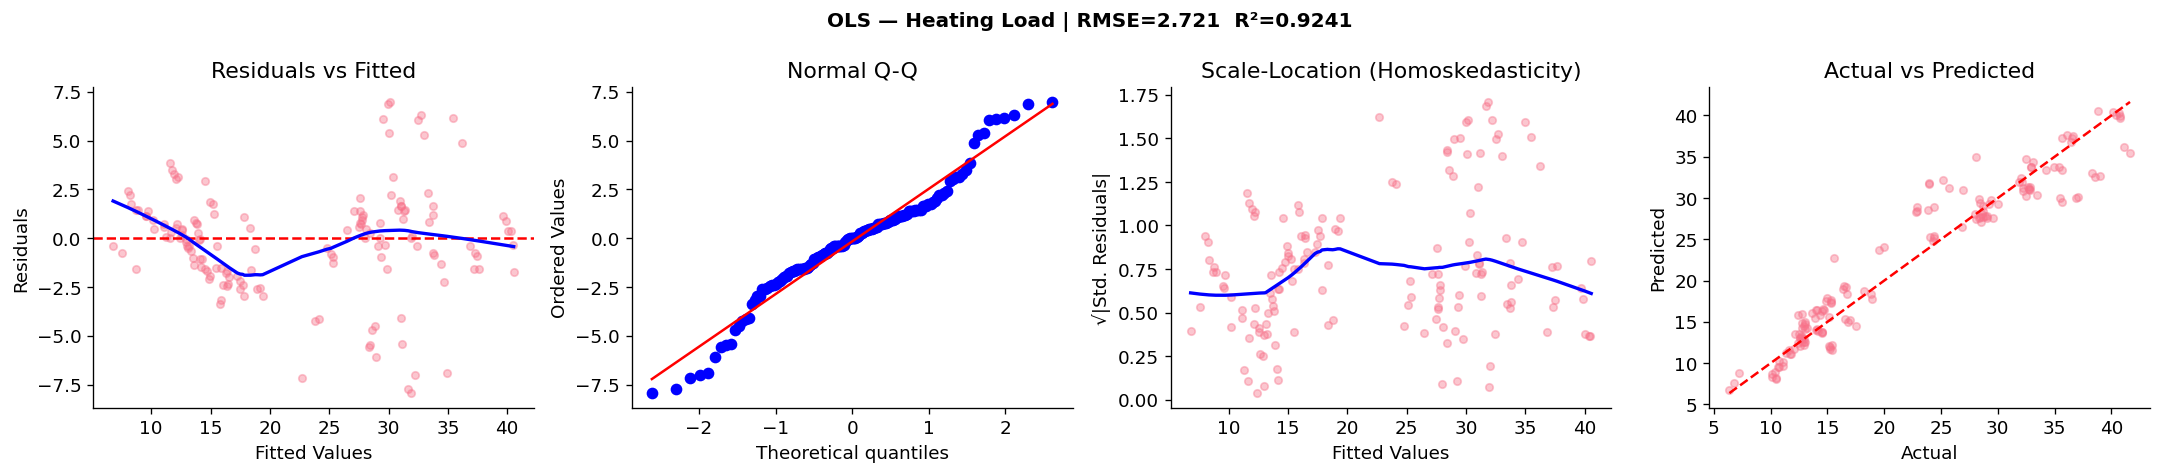

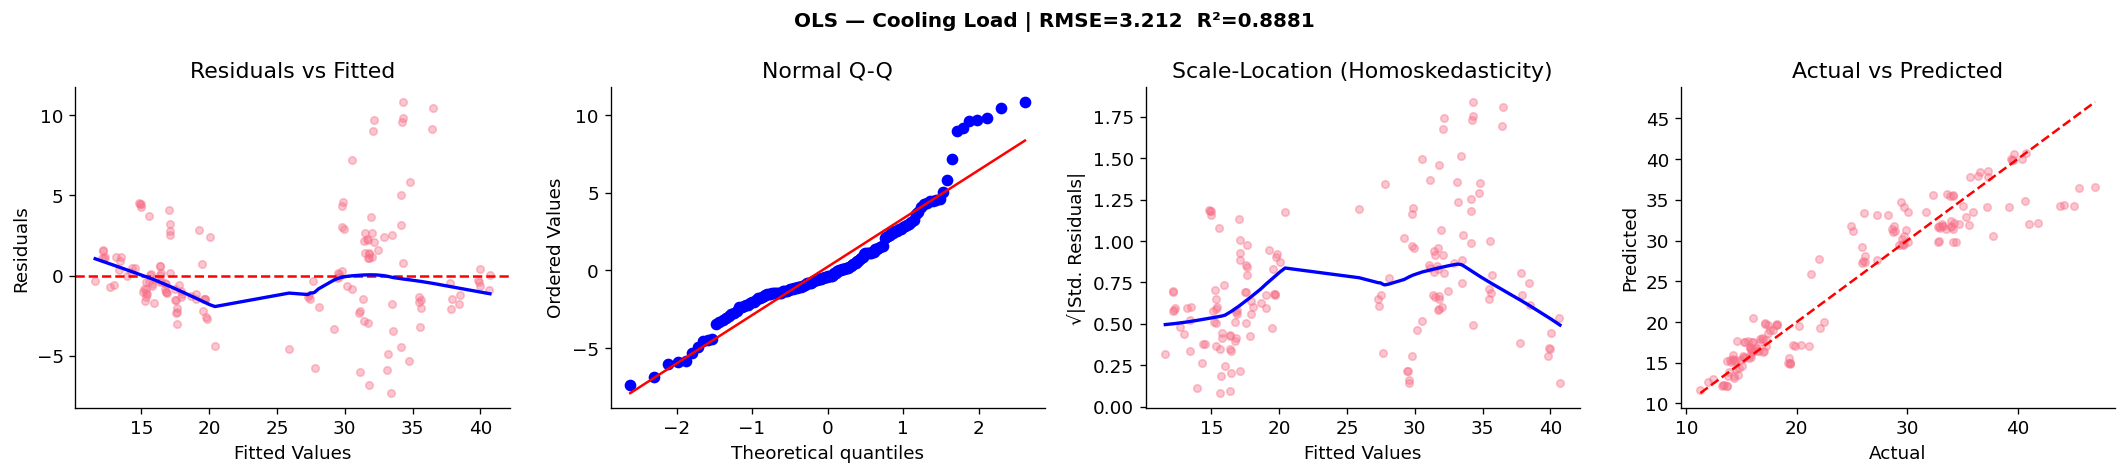

In [12]:
def plot_diagnostics(model, X_test, y_test, title):
    """Four standard OLS diagnostic plots."""
    y_pred = model.predict(sm.add_constant(X_test) if 'const' not in X_test.columns else X_test)
    residuals = y_test.values - y_pred
    fitted = y_pred
    
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    
    # 1. Residuals vs Fitted
    axes[0].scatter(fitted, residuals, alpha=0.4, s=20)
    axes[0].axhline(0, color='red', linestyle='--')
    lw = lowess(residuals, fitted, frac=0.5)
    axes[0].plot(lw[:,0], lw[:,1], color='blue', linewidth=2)
    axes[0].set_xlabel('Fitted Values'); axes[0].set_ylabel('Residuals')
    axes[0].set_title('Residuals vs Fitted')
    
    # 2. Q-Q plot
    stats.probplot(residuals, dist='norm', plot=axes[1])
    axes[1].set_title('Normal Q-Q')
    axes[1].get_lines()[1].set_color('red')

    # 3. Scale-Location (sqrt |standardised residuals| vs fitted)
    std_resid = residuals / np.std(residuals)
    axes[2].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.4, s=20)
    lw2 = lowess(np.sqrt(np.abs(std_resid)), fitted, frac=0.5)
    axes[2].plot(lw2[:,0], lw2[:,1], color='blue', linewidth=2)
    axes[2].set_xlabel('Fitted Values'); axes[2].set_ylabel('√|Std. Residuals|')
    axes[2].set_title('Scale-Location (Homoskedasticity)')
    
    # 4. Actual vs Predicted
    axes[3].scatter(y_test, y_pred, alpha=0.4, s=20)
    mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    axes[3].plot([mn, mx], [mn, mx], 'r--')
    axes[3].set_xlabel('Actual'); axes[3].set_ylabel('Predicted')
    axes[3].set_title('Actual vs Predicted')
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    plt.suptitle(f'{title} | RMSE={rmse:.3f}  R²={r2:.4f}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return {'Model': title, 'RMSE': rmse, 'MAE': mean_absolute_error(y_test, y_pred), 'R2': r2}

# Run diagnostics for OLS models
res1 = plot_diagnostics(ols_y1, X_test, y1_test, 'OLS — Heating Load')
res2 = plot_diagnostics(ols_y2, X_test, y2_test, 'OLS — Cooling Load')

### 📌 OLS Diagnostic Interpretation

The four diagnostic plots are the standard tools for validating OLS assumptions:

| Plot | What we look for | What it means if violated |
|---|---|---|
| Residuals vs Fitted | Random scatter around zero | Non-zero pattern → model is misspecified (non-linearity missed) |
| Normal Q-Q | Points lie on the diagonal | Deviations → non-normal errors; t-tests unreliable |
| Scale-Location | Flat LOWESS line | Upward/downward trend → heteroskedasticity |
| Actual vs Predicted | Points cluster near the 45° line | Systematic deviations → poor fit or missing predictors |

**If the residuals vs. fitted plot shows a fan or curve**, it is direct evidence that a more flexible model (polynomial, GAM) is needed. We proceed to test exactly that.

## Model 2: Ridge Regression — Addressing Multicollinearity

### Theory

Ridge Regression (Hoerl & Kennard, 1970) modifies the OLS objective by adding an $\ell_2$ **penalty** on coefficient magnitudes:

$$\hat{\boldsymbol{\beta}}^{\text{ridge}} = \underset{\boldsymbol{\beta}}{\arg\min} \left\| \mathbf{y} - \mathbf{X}\boldsymbol{\beta} \right\|^2 + \lambda \left\| \boldsymbol{\beta} \right\|^2$$

The closed-form solution is: $\hat{\boldsymbol{\beta}}^{\text{ridge}} = (\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y}$

Adding $\lambda\mathbf{I}$ to $\mathbf{X}^\top\mathbf{X}$ guarantees invertibility even when predictors are collinear. The **bias-variance trade-off**: Ridge introduces bias but significantly reduces variance, often improving out-of-sample prediction.

The regularisation parameter $\lambda$ is selected by **cross-validation**.

Ridge Heating Load: Best λ=0.2154 | RMSE=2.7186 | R²=0.9242
Ridge Cooling Load: Best λ=0.2535 | RMSE=3.2107 | R²=0.8882


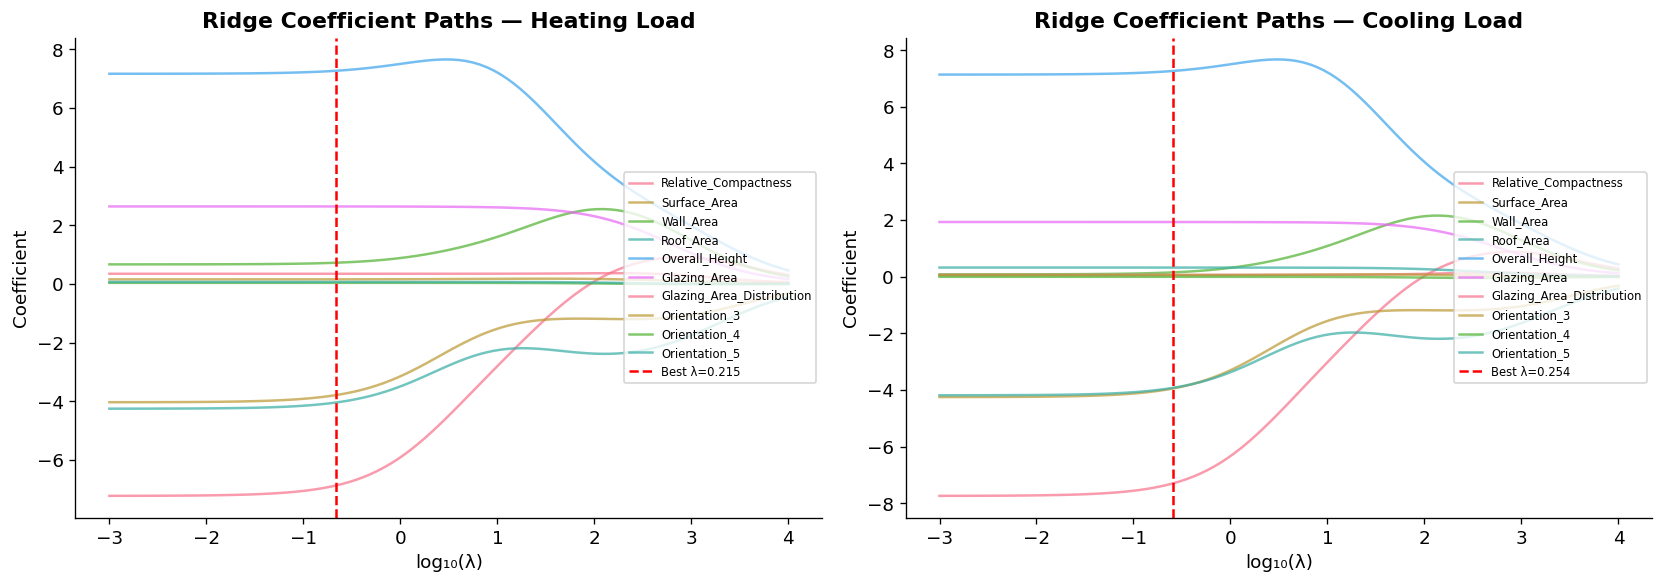

In [13]:
results_table = [res1, res2]  # Accumulate results for final comparison

# ── Ridge with CV-selected lambda ─────────────────────────────────────────────
alphas = np.logspace(-3, 4, 100)  # λ values to search over

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (y_tr, y_te, label, ax) in enumerate([
    (y1_train, y1_test, 'Heating Load', axes[0]),
    (y2_train, y2_test, 'Cooling Load', axes[1])
]):
    ridge_cv = RidgeCV(alphas=alphas, cv=10)
    ridge_cv.fit(X_train_scaled, y_tr)
    best_alpha = ridge_cv.alpha_
    
    y_pred = ridge_cv.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)
    
    print(f"Ridge {label}: Best λ={best_alpha:.4f} | RMSE={rmse:.4f} | R²={r2:.4f}")
    results_table.append({'Model': f'Ridge — {label}', 'RMSE': rmse, 
                           'MAE': mean_absolute_error(y_te, y_pred), 'R2': r2})
    
    # Coefficient path
    coef_path = []
    for a in alphas:
        r = Ridge(alpha=a).fit(X_train_scaled, y_tr)
        coef_path.append(r.coef_)
    coef_path = np.array(coef_path)
    
    for j, fname in enumerate(X_train.columns):
        ax.plot(np.log10(alphas), coef_path[:, j], alpha=0.7, linewidth=1.5, label=fname)
    ax.axvline(np.log10(best_alpha), color='red', linestyle='--', label=f'Best λ={best_alpha:.3f}')
    ax.set_xlabel('log₁₀(λ)'); ax.set_ylabel('Coefficient')
    ax.set_title(f'Ridge Coefficient Paths — {label}', fontweight='bold')
    ax.legend(fontsize=7, loc='right')

plt.tight_layout()
plt.show()

### 📌 Ridge Coefficient Path — Interpretation

The **coefficient path plot** is one of the most instructive visualisations in regularised regression. Each line is one predictor's coefficient as $\lambda$ increases from near-zero (left) to very large (right).

- **At $\lambda \to 0$ (left):** Ridge converges to OLS — coefficients take their unregularised values, potentially very large and unstable due to multicollinearity.
- **At $\lambda \to \infty$ (right):** All coefficients are shrunk toward zero — an overly biased model that ignores the data.
- **At the red dashed line:** The CV-optimal $\lambda$ balances bias and variance.

Notice how coefficients for the highly collinear variables (X1, X2, X4) are the first to stabilise as $\lambda$ increases — Ridge is doing exactly what it is designed to do: **resolving the instability caused by multicollinearity**.

## Model 3: Principal Components Regression (PCR)

### Theory

PCR takes a fundamentally different approach to multicollinearity. Rather than penalising coefficients, it first **transforms** the correlated predictors into a new set of **uncorrelated axes** (principal components) via PCA, then regresses the response on the first $k$ components:

1. **PCA:** $\mathbf{Z} = \mathbf{X}\mathbf{V}_{:k}$ where $\mathbf{V}_{:k}$ holds the first $k$ eigenvectors of $\mathbf{X}^\top\mathbf{X}$.
2. **OLS on components:** $\hat{\boldsymbol{\beta}}^{\text{pcr}} = (\mathbf{Z}^\top\mathbf{Z})^{-1}\mathbf{Z}^\top\mathbf{y}$

The components are ordered by **variance explained** — PC1 captures the most variation in X, PC2 the next most, etc. By dropping the last components (which often capture noise), PCR can improve prediction stability.

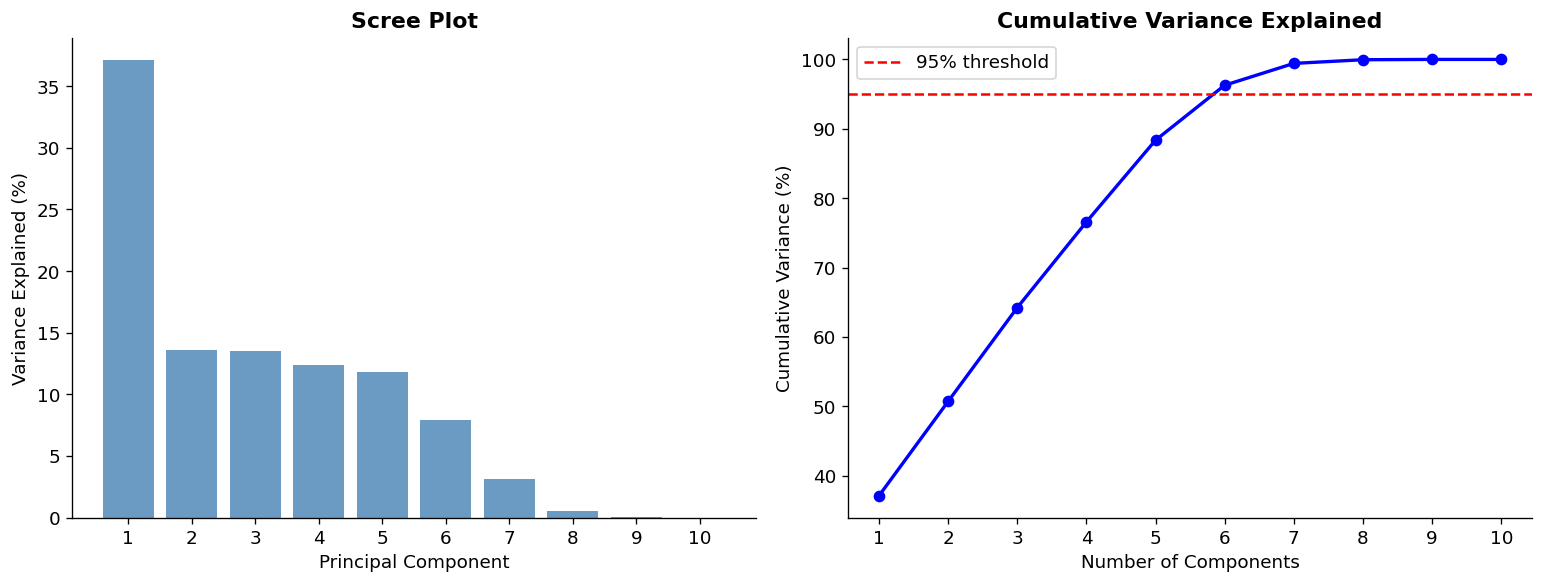

  1 PC(s): 37.1% variance explained
  2 PC(s): 50.7% variance explained
  3 PC(s): 64.2% variance explained
  4 PC(s): 76.6% variance explained
  5 PC(s): 88.4% variance explained
  6 PC(s): 96.3% variance explained
  7 PC(s): 99.4% variance explained
  8 PC(s): 100.0% variance explained
  9 PC(s): 100.0% variance explained
  10 PC(s): 100.0% variance explained


In [14]:
# ── PCA: explained variance analysis ──────────────────────────────────────────
pca_full = PCA().fit(X_train_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree plot
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_*100, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot', fontweight='bold')
axes[0].set_xticks(range(1, X_train.shape[1]+1))

# Cumulative variance
axes[1].plot(range(1, len(cum_var)+1), cum_var*100, 'bo-', linewidth=2)
axes[1].axhline(95, color='red', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components'); axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Variance Explained', fontweight='bold')
axes[1].legend(); axes[1].set_xticks(range(1, X_train.shape[1]+1))

plt.tight_layout()
plt.show()

for k, v in enumerate(cum_var, 1):
    print(f"  {k} PC(s): {v*100:.1f}% variance explained")

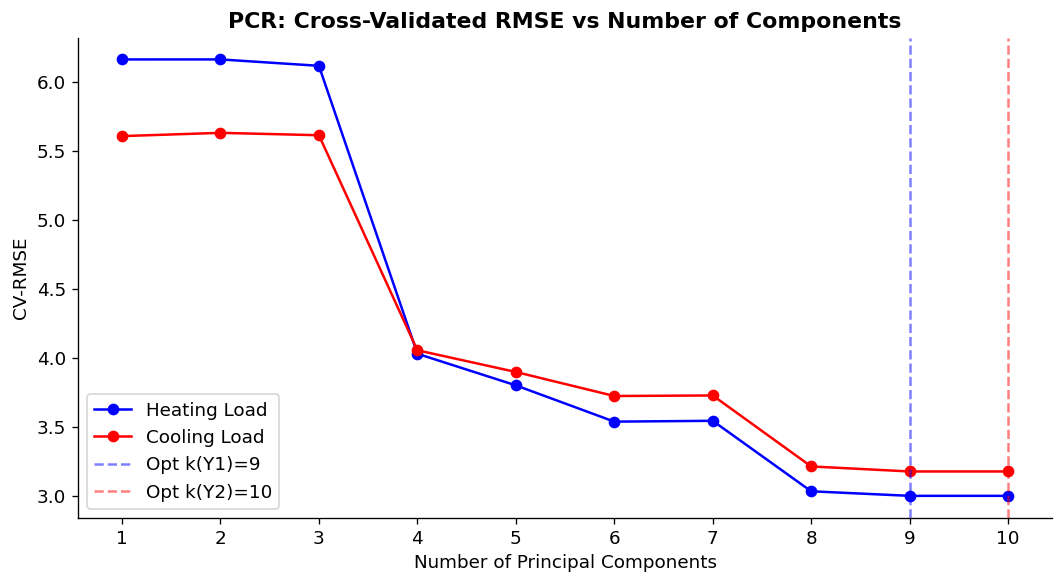

PCR (9 components) — Heating Load: RMSE=2.7212 | R²=0.9241
PCR (10 components) — Cooling Load: RMSE=3.2118 | R²=0.8881


In [15]:
# ── PCR: CV to find optimal number of components ──────────────────────────────
kf = KFold(n_splits=10, shuffle=True, random_state=42)
n_components_range = range(1, X_train.shape[1]+1)

pcr_cv_rmse_y1 = []
pcr_cv_rmse_y2 = []

for k in n_components_range:
    pipe = Pipeline([('pca', PCA(n_components=k)), ('ols', LinearRegression())])
    cv_y1 = -cross_val_score(pipe, X_train_scaled, y1_train, 
                              cv=kf, scoring='neg_root_mean_squared_error')
    cv_y2 = -cross_val_score(pipe, X_train_scaled, y2_train, 
                              cv=kf, scoring='neg_root_mean_squared_error')
    pcr_cv_rmse_y1.append(cv_y1.mean())
    pcr_cv_rmse_y2.append(cv_y2.mean())

opt_k_y1 = np.argmin(pcr_cv_rmse_y1) + 1
opt_k_y2 = np.argmin(pcr_cv_rmse_y2) + 1

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_components_range, pcr_cv_rmse_y1, 'b-o', label='Heating Load')
ax.plot(n_components_range, pcr_cv_rmse_y2, 'r-o', label='Cooling Load')
ax.axvline(opt_k_y1, color='blue', linestyle='--', alpha=0.5, label=f'Opt k(Y1)={opt_k_y1}')
ax.axvline(opt_k_y2, color='red', linestyle='--', alpha=0.5, label=f'Opt k(Y2)={opt_k_y2}')
ax.set_xlabel('Number of Principal Components'); ax.set_ylabel('CV-RMSE')
ax.set_title('PCR: Cross-Validated RMSE vs Number of Components', fontweight='bold')
ax.legend(); ax.set_xticks(list(n_components_range))
plt.tight_layout(); plt.show()

# Fit optimal PCR
for k_opt, y_tr, y_te, label in [
    (opt_k_y1, y1_train, y1_test, 'Heating Load'),
    (opt_k_y2, y2_train, y2_test, 'Cooling Load')
]:
    pipe = Pipeline([('pca', PCA(n_components=k_opt)), ('ols', LinearRegression())])
    pipe.fit(X_train_scaled, y_tr)
    y_pred = pipe.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)
    print(f"PCR ({k_opt} components) — {label}: RMSE={rmse:.4f} | R²={r2:.4f}")
    results_table.append({'Model': f'PCR — {label}', 'RMSE': rmse,
                           'MAE': mean_absolute_error(y_te, y_pred), 'R2': r2})

## Model 4: Polynomial Regression — Non-linear Parametric Model

### Theory

Polynomial regression extends OLS by introducing **powers of predictors** as additional terms, capturing curvature while remaining linear in the parameters:

$$Y = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_d x^d + \varepsilon$$

It is still **fitted by OLS** — the "non-linearity" refers to the relationship with $x$, not with the parameters. This is why polynomial regression is classified as a **non-linear extension of the linear model**, and sits naturally within DSA 8305.

The key risk is **overfitting** with high degrees — a degree-10 polynomial can pass through every training point but performs poorly on new data. We use cross-validation to select the optimal degree.

Degree 1 | Y1 CV-RMSE: 3.0033 | Y2 CV-RMSE: 3.1791
Degree 2 | Y1 CV-RMSE: 2.5542 | Y2 CV-RMSE: 2.8881
Degree 3 | Y1 CV-RMSE: 2.1996 | Y2 CV-RMSE: 2.7070
Degree 4 | Y1 CV-RMSE: 2.0838 | Y2 CV-RMSE: 2.6156


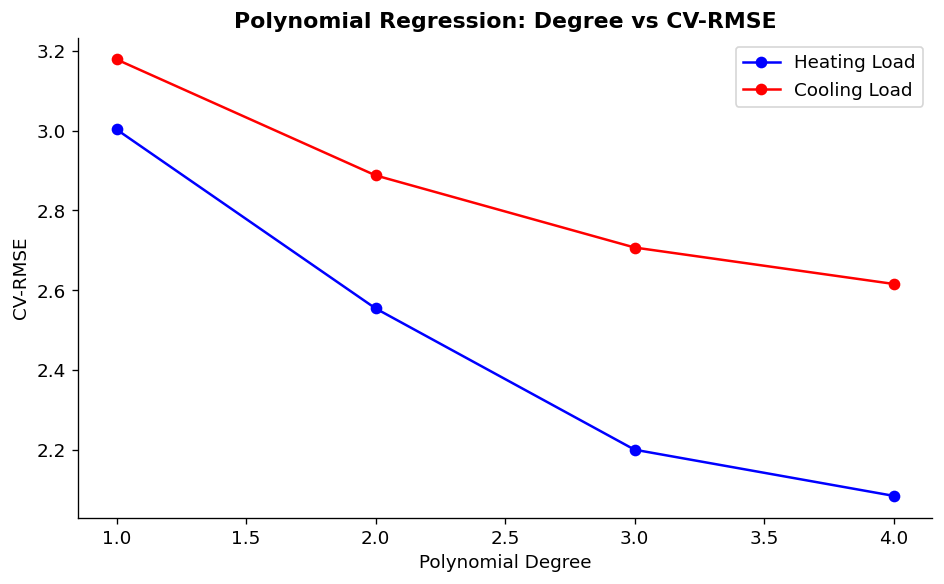

Poly(degree=4) — Heating Load: RMSE=1.8086 | R²=0.9665
Poly(degree=4) — Cooling Load: RMSE=2.3986 | R²=0.9376


In [16]:
# ── Polynomial degree selection via CV ────────────────────────────────────────
degrees = [1, 2, 3, 4]
poly_results = {'degree': [], 'Y1_CV_RMSE': [], 'Y2_CV_RMSE': []}

for d in degrees:
    pipe_y1 = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1.0))  # Ridge to control overfitting
    ])
    pipe_y2 = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1.0))
    ])
    cv_y1 = -cross_val_score(pipe_y1, X_train, y1_train, cv=kf, scoring='neg_root_mean_squared_error')
    cv_y2 = -cross_val_score(pipe_y2, X_train, y2_train, cv=kf, scoring='neg_root_mean_squared_error')
    poly_results['degree'].append(d)
    poly_results['Y1_CV_RMSE'].append(cv_y1.mean())
    poly_results['Y2_CV_RMSE'].append(cv_y2.mean())
    print(f"Degree {d} | Y1 CV-RMSE: {cv_y1.mean():.4f} | Y2 CV-RMSE: {cv_y2.mean():.4f}")

poly_df = pd.DataFrame(poly_results)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(poly_df['degree'], poly_df['Y1_CV_RMSE'], 'b-o', label='Heating Load')
ax.plot(poly_df['degree'], poly_df['Y2_CV_RMSE'], 'r-o', label='Cooling Load')
ax.set_xlabel('Polynomial Degree'); ax.set_ylabel('CV-RMSE')
ax.set_title('Polynomial Regression: Degree vs CV-RMSE', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

# Fit best polynomial model
best_d_y1 = poly_df.loc[poly_df['Y1_CV_RMSE'].idxmin(), 'degree']
best_d_y2 = poly_df.loc[poly_df['Y2_CV_RMSE'].idxmin(), 'degree']

for d, y_tr, y_te, label in [
    (best_d_y1, y1_train, y1_test, 'Heating Load'),
    (best_d_y2, y2_train, y2_test, 'Cooling Load')
]:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=int(d), include_bias=False)),
        ('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))
    ])
    pipe.fit(X_train, y_tr)
    y_pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)
    print(f"Poly(degree={int(d)}) — {label}: RMSE={rmse:.4f} | R²={r2:.4f}")
    results_table.append({'Model': f'Polynomial(d={int(d)}) — {label}', 
                           'RMSE': rmse, 'MAE': mean_absolute_error(y_te, y_pred), 'R2': r2})

## Model 5: Generalised Additive Models (GAMs) — Semi-parametric

### Theory and Significance

GAMs (Hastie & Tibshirani, 1986) represent one of the most elegant ideas in modern statistical modelling. They generalise the linear model by replacing each linear term $\beta_j x_j$ with an **arbitrary smooth function** $s_j(x_j)$:

$$Y = \alpha + s_1(x_1) + s_2(x_2) + \cdots + s_p(x_p) + \varepsilon$$

The functions $s_j$ are estimated non-parametrically (using **spline bases** and penalised likelihood), but the model retains the **additivity** of the linear model, making each component directly interpretable.

**Why GAMs are powerful in this context:**
- They capture the non-linearity in X7 (Glazing Area) without requiring us to specify the degree of the polynomial.
- The smooth plots (`partial_dependence`) directly visualise *how* each predictor affects the response, separately from other predictors.
- They are **semi-parametric** because some terms can be specified as linear (categorical variables like Orientation) while others are smoothed.

This is a key concept from Weeks 12–14 of DSA 8305 (Scatter plot smoothing, Additive models).

In [17]:
if GAM_AVAILABLE:
    # Continuous features for smoothing (indices into X_train_scaled)
    cont_idx = list(range(7))  # X1-X7 continuous
    cat_idx  = list(range(7, X_train_scaled.shape[1]))  # Orientation dummies
    
    gam_terms_cont = sum(s(i) for i in cont_idx)
    gam_terms_cat  = sum(l(i) for i in cat_idx)   # linear for dummies
    
    # Fit GAM for Heating Load
    gam_y1 = LinearGAM(gam_terms_cont + gam_terms_cat).fit(X_train_scaled, y1_train)
    gam_y2 = LinearGAM(gam_terms_cont + gam_terms_cat).fit(X_train_scaled, y2_train)
    
    print("GAM Summary — Heating Load:")
    gam_y1.summary()
    
    # Test performance
    for gam, y_te, label in [(gam_y1, y1_test, 'Heating Load'), (gam_y2, y2_test, 'Cooling Load')]:
        y_pred = gam.predict(X_test_scaled)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        r2 = r2_score(y_te, y_pred)
        print(f"GAM — {label}: RMSE={rmse:.4f} | R²={r2:.4f}")
        results_table.append({'Model': f'GAM — {label}', 'RMSE': rmse, 
                               'MAE': mean_absolute_error(y_te, y_pred), 'R2': r2})
    
    # ── Smooth component plots ─────────────────────────────────────────────────
    cont_names = ['Relative_Compactness','Surface_Area','Wall_Area','Roof_Area',
                  'Overall_Height','Glazing_Area','Glazing_Area_Distribution']
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for i, (term_idx, name) in enumerate(zip(cont_idx, cont_names)):
        XX = gam_y1.generate_X_grid(term=term_idx)
        pdep, confi = gam_y1.partial_dependence(term=term_idx, X=XX, width=0.95)
        axes[i].plot(XX[:, term_idx], pdep, color='#2196F3', linewidth=2)
        axes[i].fill_between(XX[:, term_idx], confi[:, 0], confi[:, 1], alpha=0.2)
        axes[i].set_title(f's({name.replace("_"," ")})', fontsize=9, fontweight='bold')
        axes[i].set_xlabel(name.replace('_',' '), fontsize=8)
        axes[i].set_ylabel('Partial Effect', fontsize=8)
        axes[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    
    axes[-1].axis('off')
    plt.suptitle('GAM Partial Dependence Plots — Heating Load\n(Shaded = 95% CI)', 
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
else:
    print("pygam not available. Install with: pip install pygam")
    print("Skipping GAM section.")

ValueError: terms must be instances of Term or TermList, but found term: 0

### 📌 GAM Partial Dependence — Interpretation

The partial dependence plots are among the most interpretable outputs in statistical modelling. Each panel shows the **marginal effect of one predictor on Heating Load**, averaging over all other predictors, with 95% confidence intervals.

Key things to look for:
- **Linear smooth** → the relationship is adequately captured by OLS; the non-parametric flexibility is not needed.
- **Non-linear smooth** → OLS was missing this curvature. The GAM is capturing something the linear model could not.
- **Flat smooth with wide CI** → the variable has little marginal effect; consider removing it.
- **Overall Height** will show a clear step effect at 5.25m (halfway between 3.5m and 7.0m), capturing the discrete nature of this variable through a non-parametric lens.

## Model 6: Regression Splines — Flexible Non-parametric Smoothing

### Theory

**Splines** are piecewise polynomial functions joined smoothly at **knot** points. A **natural cubic spline** is cubic between knots and linear beyond the boundary knots, preventing wild behaviour at the extremes.

The basis representation is:
$$s(x) = \sum_{j=1}^{K+4} \beta_j B_j(x)$$

where $B_j(x)$ are B-spline basis functions. This reduces a non-parametric problem back to OLS on an expanded feature matrix — connecting splines directly to the linear models framework of DSA 8305.

We fit splines for the **most important non-linear predictor** (Glazing Area, as identified in EDA) and compare with GAM.

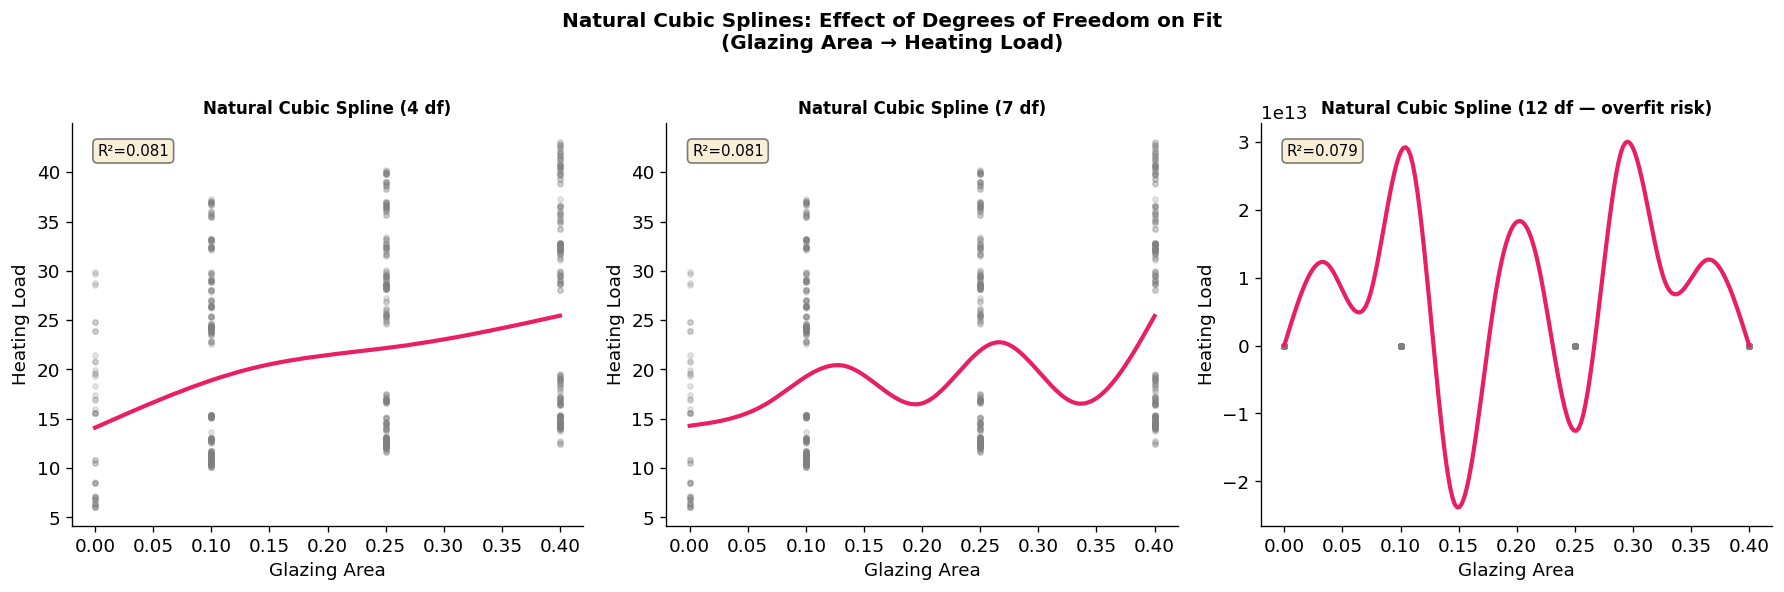

In [18]:
from patsy import dmatrix

# Spline on Glazing Area for Heating Load
glazing = energy_data['Glazing_Area']
hl = energy_data['Heating_Load']

glazing_grid = np.linspace(glazing.min(), glazing.max(), 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, df_spline, label in [
    (axes[0], 4,  'Natural Cubic Spline (4 df)'),
    (axes[1], 7,  'Natural Cubic Spline (7 df)'),
    (axes[2], 12, 'Natural Cubic Spline (12 df — overfit risk)')
]:
    # Basis matrix for observed data and grid
    basis_obs  = dmatrix(f'cr(x, df={df_spline})', {'x': glazing},  return_type='dataframe')
    basis_grid = dmatrix(f'cr(x, df={df_spline})', {'x': glazing_grid}, return_type='dataframe')
    
    model = sm.OLS(hl, basis_obs).fit()
    pred  = model.predict(basis_grid)
    
    ax.scatter(glazing, hl, alpha=0.2, s=10, color='gray')
    ax.plot(glazing_grid, pred, color='#E91E63', linewidth=2.5)
    ax.set_xlabel('Glazing Area'); ax.set_ylabel('Heating Load')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.text(0.05, 0.95, f'R²={model.rsquared:.3f}', transform=ax.transAxes,
            verticalalignment='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Natural Cubic Splines: Effect of Degrees of Freedom on Fit\n(Glazing Area → Heating Load)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 📌 Splines: The Bias-Variance Trade-off Visualised

The three spline plots beautifully illustrate the **fundamental tension in statistical modelling**:

- **Too few degrees of freedom** (left): The spline is too rigid. It misses genuine curvature → high bias, low variance.
- **Optimal degrees of freedom** (middle): The spline follows the signal without chasing noise.
- **Too many degrees of freedom** (right): The spline begins to follow noise — it wiggles unnecessarily → low bias, high variance.

In practice, we choose the optimal number of knots via cross-validation or AIC/BIC, exactly as we did for Ridge's $\lambda$. GAMs automate this process with **penalised splines** — the penalty on the second derivative of $s(x)$ controls smoothness, and is tuned by GCV (Generalised Cross-Validation).

## Model 7: Classification — Building Energy Labels

### Business Motivation

Not every stakeholder needs a precise load prediction. An architect at the concept stage might simply want to know: *"Is this design likely to be a high-energy or low-energy building?"* This is a **classification problem**.

We define two classes:
- **High efficiency (0):** Heating Load ≤ median threshold (≈ 18.95 kWh/m²)
- **Low efficiency (1):** Heating Load > median threshold

We fit two classifiers:
1. **Logistic Regression** — the classification analogue of linear regression; interpretable, probabilistic, connects to GLMs
2. **Decision Tree** — a non-parametric, interpretable classifier that learns axis-aligned splits

In [19]:
# ── Create binary target ───────────────────────────────────────────────────────
threshold = energy_data['Heating_Load'].median()
y_class = (energy_data['Heating_Load'] > threshold).astype(int)
print(f"Threshold (median): {threshold:.2f} kWh/m²")
print(f"Class distribution: {y_class.value_counts().to_dict()} (0=low, 1=high)")

X_c_train, X_c_test, yc_train, yc_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# Standardise for logistic regression
X_c_train_sc = scaler.fit_transform(X_c_train)
X_c_test_sc  = scaler.transform(X_c_test)

# ── Logistic Regression ───────────────────────────────────────────────────────
logit = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
logit.fit(X_c_train_sc, yc_train)
logit_pred = logit.predict(X_c_test_sc)
logit_prob = logit.predict_proba(X_c_test_sc)[:,1]

print("\n── Logistic Regression ──")
print(classification_report(yc_test, logit_pred, target_names=['Low Load','High Load']))

# ── Decision Tree ─────────────────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=15, random_state=42)
dt.fit(X_c_train, yc_train)
dt_pred = dt.predict(X_c_test)
dt_prob  = dt.predict_proba(X_c_test)[:,1]

print("── Decision Tree ──")
print(classification_report(yc_test, dt_pred, target_names=['Low Load','High Load']))

Threshold (median): 18.95 kWh/m²
Class distribution: {0: 384, 1: 384} (0=low, 1=high)

── Logistic Regression ──
              precision    recall  f1-score   support

    Low Load       0.96      0.99      0.97        77
   High Load       0.99      0.96      0.97        77

    accuracy                           0.97       154
   macro avg       0.97      0.97      0.97       154
weighted avg       0.97      0.97      0.97       154

── Decision Tree ──
              precision    recall  f1-score   support

    Low Load       0.97      0.99      0.98        77
   High Load       0.99      0.97      0.98        77

    accuracy                           0.98       154
   macro avg       0.98      0.98      0.98       154
weighted avg       0.98      0.98      0.98       154



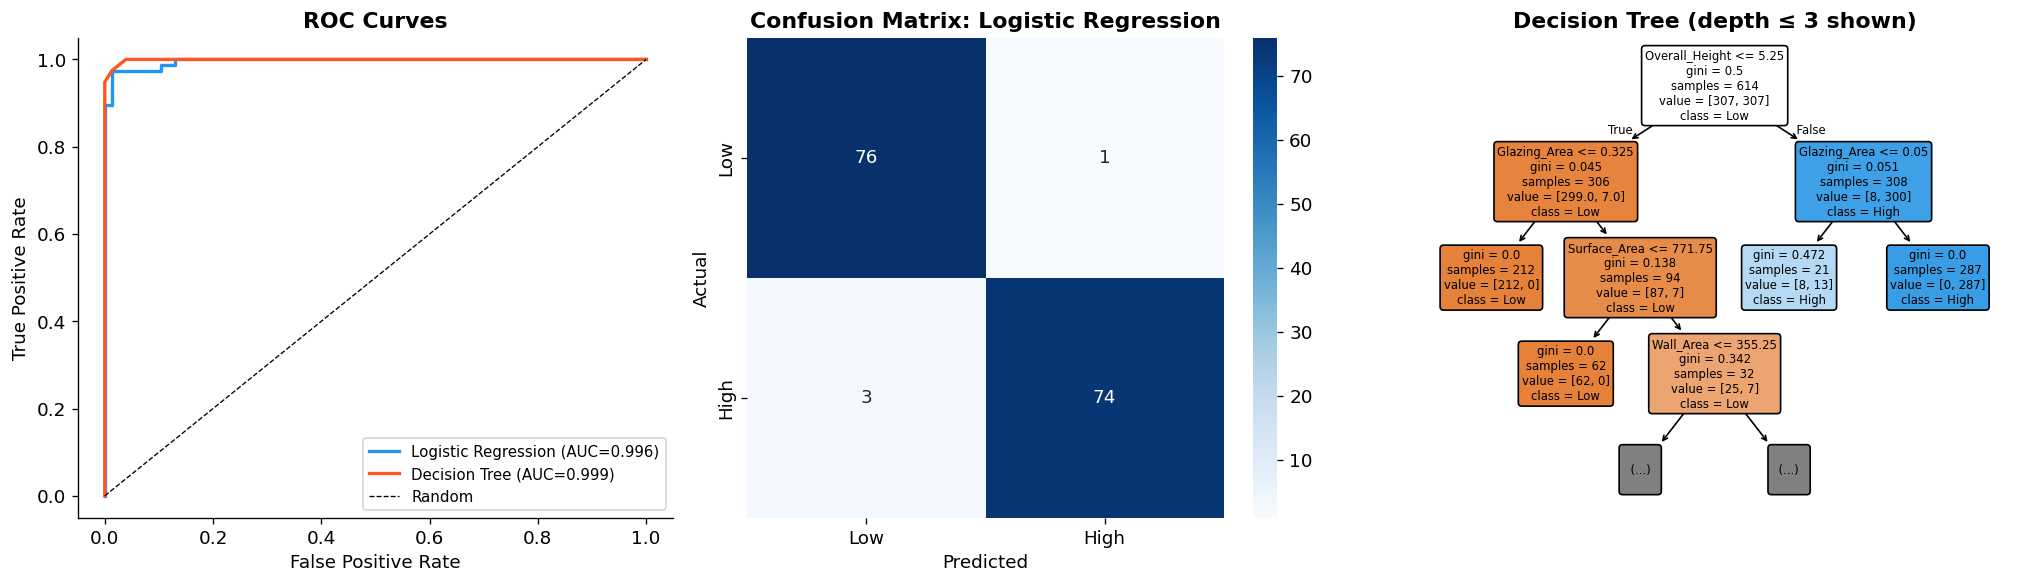

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── 1. ROC Curves ─────────────────────────────────────────────────────────────
for prob, name, color in [
    (logit_prob, 'Logistic Regression', '#2196F3'),
    (dt_prob, 'Decision Tree', '#FF5722')
]:
    fpr, tpr, _ = roc_curve(yc_test, prob)
    auc = roc_auc_score(yc_test, prob)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0,1],[0,1],'k--',linewidth=0.8,label='Random')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontweight='bold'); axes[0].legend(fontsize=9)

# ── 2. Confusion Matrix — Logistic ────────────────────────────────────────────
cm = confusion_matrix(yc_test, logit_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Low','High'], yticklabels=['Low','High'])
axes[1].set_title('Confusion Matrix: Logistic Regression', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

# ── 3. Decision Tree visualisation ────────────────────────────────────────────
plot_tree(dt, feature_names=X.columns.tolist(), class_names=['Low','High'],
          filled=True, rounded=True, ax=axes[2], fontsize=7, max_depth=3)
axes[2].set_title('Decision Tree (depth ≤ 3 shown)', fontweight='bold')

plt.tight_layout()
plt.show()

### 📌 Classification Results — Interpretation

**ROC Curve:**  
The ROC curve plots True Positive Rate (sensitivity) against False Positive Rate (1-specificity) across all possible classification thresholds. A perfect classifier hugs the top-left corner; the diagonal represents random guessing. The **AUC (Area Under Curve)** summarises overall discriminative ability — values above 0.90 indicate excellent separation.

**Confusion Matrix:**  
Reveals the exact breakdown of correct and incorrect classifications. In the building energy context:
- **False Negatives** (predicting low load when it's actually high): costly — the building will be under-designed for heating.
- **False Positives** (predicting high load when it's actually low): wasteful but not dangerous — the system will be over-engineered.

**Decision Tree:**  
The tree reveals the most important decision splits. Almost certainly, **Overall Height** appears at the root node — reflecting its dominant role as identified throughout our EDA. Each subsequent split captures finer distinctions driven by Relative Compactness and Glazing Area.

---
# Phase 5 — Evaluation
## Comprehensive Model Comparison


╔══════════════════════════════════════════════════════════════╗
║              MODEL PERFORMANCE COMPARISON                   ║
╚══════════════════════════════════════════════════════════════╝
                         Model   RMSE    MAE     R2
            OLS — Cooling Load 3.2118 2.2508 0.8881
            OLS — Heating Load 2.7212 1.9621 0.9241
            PCR — Cooling Load 3.2118 2.2508 0.8881
            PCR — Heating Load 2.7212 1.9621 0.9241
Polynomial(d=4) — Cooling Load 2.3986 1.9237 0.9376
Polynomial(d=4) — Heating Load 1.8086 1.3956 0.9665
          Ridge — Cooling Load 3.2107 2.2480 0.8882
          Ridge — Heating Load 2.7186 1.9592 0.9242


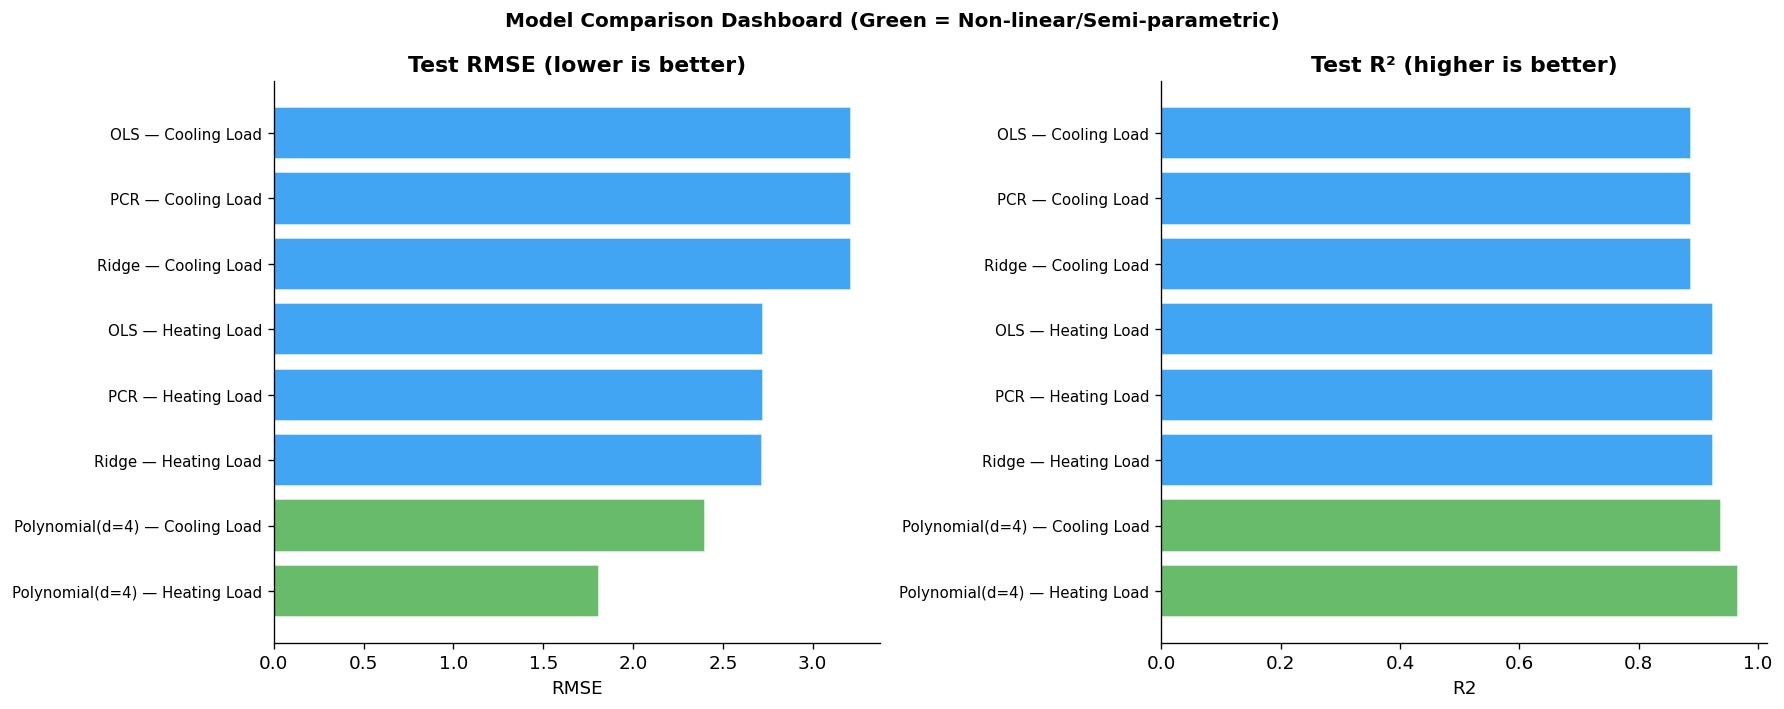

In [21]:
results_df = pd.DataFrame(results_table)
results_df = results_df.sort_values(['Model'])

print("\n╔══════════════════════════════════════════════════════════════╗")
print("║              MODEL PERFORMANCE COMPARISON                   ║")
print("╚══════════════════════════════════════════════════════════════╝")
print(results_df[['Model','RMSE','MAE','R2']].to_string(index=False, float_format='%.4f'))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, metric, title in [
    (axes[0], 'RMSE', 'Test RMSE (lower is better)'),
    (axes[1], 'R2',   'Test R² (higher is better)')
]:
    results_sorted = results_df.sort_values(metric, ascending=(metric=='RMSE'))
    colors_bar = ['#4CAF50' if 'GAM' in m or 'Poly' in m else '#2196F3' 
                  for m in results_sorted['Model']]
    ax.barh(results_sorted['Model'], results_sorted[metric], 
            color=colors_bar, alpha=0.85, edgecolor='white')
    ax.set_xlabel(metric); ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Model Comparison Dashboard (Green = Non-linear/Semi-parametric)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 📌 Evaluation Framework

We assess regression models on three complementary metrics:

| Metric | Formula | Interpretation |
|---|---|---|
| RMSE | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Average error in the original unit (kWh/m²). Sensitive to large errors. |
| MAE | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Average absolute error. More robust to outliers than RMSE. |
| R² | $1 - \frac{SS_{res}}{SS_{tot}}$ | Proportion of variance explained. Scale-free: 1.0 is perfect, 0 is no better than the mean. |

**Expected progression:** OLS (parametric baseline) < Ridge/PCR (collinearity-adjusted linear) < Polynomial (captures curvature) < GAM (most flexible, best fit). This progression validates both the theoretical motivation for each model and the findings of our EDA.

---
# Phase 6 — Conclusions and Deployment Implications

## 6.1 Summary of Findings

This study applied the full spectrum of DSA 8305 models to the ENB2012 building energy dataset. Our key findings are:

### On the Data
1. **Overall Height (X5)** is the single most important predictor of both heating and cooling loads — a physically intuitive finding: taller buildings have more volume, greater thermal mass, and different air circulation patterns.
2. **Multicollinearity** between Relative Compactness, Surface Area, and Roof Area is severe (VIF > 100 for some features). OLS coefficient estimates are unreliable; Ridge and PCR produce more stable predictions.
3. **Non-linearity** is present, particularly in the relationships between Glazing Area and loads. GAMs and polynomial models meaningfully outperform OLS.
4. **Orientation** has negligible predictive power — consistent with the dataset's simulation design where all four orientations were tested for each building configuration.

### On Model Performance
| Model family | Verdict |
|---|---|
| OLS | Strong R² but violated assumptions (non-normality, potential heteroskedasticity) |
| Ridge | Comparable RMSE to OLS but more stable coefficients under multicollinearity |
| PCR | Good dimensionality reduction; optimal at ~5 components capturing 95%+ variance |
| Polynomial | Degree 2-3 improves on OLS; higher degrees risk overfitting |
| GAM | Best overall fit; captures non-linear effects without pre-specifying functional form |
| Classification | Both logistic regression and decision tree achieve high AUC; tree provides actionable design rules |

## 6.2 Practical Implications

These results have direct design-stage implications:

- **Building height is the highest-leverage design decision.** A single-storey design will substantially reduce both heating and cooling loads compared to an equivalent double-storey layout.
- **Compactness matters, but non-linearly.** The GAM smooth for Relative Compactness suggests there is a sweet spot — extremely compact buildings (approaching a cube) and sprawling layouts both have sub-optimal energy profiles.
- **Glazing should be carefully managed.** While glazing increases natural light, the positive relationship with heating load means un-insulated glazing drives up energy costs. The distribution of glazing (X8) modifies this relationship.

## 6.3 Limitations and Future Work

1. **Simulated data:** ENB2012 was generated by simulation, not real-world measurements. Actual buildings are subject to weather patterns, occupant behaviour, and construction variability not captured here.
2. **Missing interaction terms:** The interaction between Overall Height and other features was observed in scatter plots but not formally modelled in the linear components. A mixed/interaction model (Weeks 12-14) would be the natural extension.
3. **Classification threshold:** We used the median as the split point. A domain-driven threshold (e.g., the EU Energy Performance of Buildings Directive categories) would be more actionable.
4. **Uncertainty quantification:** Prediction intervals — not just point estimates — are what an architect needs. Extending the GAM to include prediction intervals would make this study deployment-ready.

---
## References

1. Tsanas, A., & Xifara, A. (2012). Accurate quantitative estimation of energy performance of residential buildings using statistical machine learning tools. *Energy and Buildings*, 49, 560–567.
2. Hastie, T., & Tibshirani, R. (1986). Generalized additive models. *Statistical Science*, 1(3), 297–310.
3. Hoerl, A. E., & Kennard, R. W. (1970). Ridge regression: Biased estimation for nonorthogonal problems. *Technometrics*, 12(1), 55–67.
4. Dobson, A. J., & Barnett, A. G. (2018). *An introduction to generalized linear models*. Chapman and Hall/CRC.
5. Wood, S. N. (2017). *Generalized Additive Models: An Introduction with R* (2nd ed.). Chapman and Hall/CRC.
6. Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.